# Dataset inspection
Run from assignments/A2. Shared preprocessing is in aoi.py. Unknown values are retained as an explicit category; duplicate records and structural Not in universe categories are preserved. All percentages here describe unweighted survey records. Final algorithms and experiments are in question2.ipynb.

In [1]:
from pathlib import Path
import pandas as pd
from aoi import load_data

path = Path("M26 DA A2/M26_DA_A2_Part2.csv")
df = load_data(path)
df.head()


,age,class_of_worker,industry_code_detailed,occupation_code_detailed,education,wage_per_hour,enrolled_in_edu_last_wk,marital_status,industry_code_major,occupation_code_major,...,country_birth_father,country_birth_mother,country_birth_self,citizenship,own_business_self_employed,vet_questionnaire,veterans_benefits,weeks_worked_in_year,year,income
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,<=50K
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,<=50K
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,<=50K
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,<=50K
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,<=50K


In [2]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.columns.tolist()

Rows: 299285
Columns: 42


['age',
 'class_of_worker',
 'industry_code_detailed',
 'occupation_code_detailed',
 'education',
 'wage_per_hour',
 'enrolled_in_edu_last_wk',
 'marital_status',
 'industry_code_major',
 'occupation_code_major',
 'race',
 'hispanic_origin',
 'sex',
 'labor_union_member',
 'unemployment_reason',
 'employment_status',
 'capital_gains',
 'capital_losses',
 'dividends',
 'tax_filer_status',
 'region_prev_residence',
 'state_prev_residence',
 'household_family_status',
 'household_summary',
 'instance_weight',
 'migration_msa',
 'migration_reg',
 'migration_within_reg',
 'live_here_1_year_ago',
 'migration_sunbelt',
 'num_persons_worked_for_employer',
 'family_members_under_18',
 'country_birth_father',
 'country_birth_mother',
 'country_birth_self',
 'citizenship',
 'own_business_self_employed',
 'vet_questionnaire',
 'veterans_benefits',
 'weeks_worked_in_year',
 'year',
 'income']

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299285 entries, 0 to 299284
Data columns (total 42 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   age                              299285 non-null  int64  
 1   class_of_worker                  299285 non-null  object 
 2   industry_code_detailed           299285 non-null  int64  
 3   occupation_code_detailed         299285 non-null  int64  
 4   education                        299285 non-null  object 
 5   wage_per_hour                    299285 non-null  int64  
 6   enrolled_in_edu_last_wk          299285 non-null  object 
 7   marital_status                   299285 non-null  object 
 8   industry_code_major              299285 non-null  object 
 9   occupation_code_major            299285 non-null  object 
 10  race                             299285 non-null  object 
 11  hispanic_origin                  299285 non-null  object 
 12  se

In [4]:
df.dtypes.value_counts()

object     29
int64      12
float64     1
Name: count, dtype: int64

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299285.0,34.538998,22.318468,0.00,15.00,33.00,50.00,90.0
industry_code_detailed,299285.0,15.345818,18.053638,0.00,0.00,0.00,33.00,51.0
occupation_code_detailed,299285.0,11.314743,14.455980,0.00,0.00,0.00,26.00,46.0
wage_per_hour,299285.0,55.105027,273.340729,0.00,0.00,0.00,0.00,9999.0
capital_gains,299285.0,431.742176,4670.768536,0.00,0.00,0.00,0.00,99999.0
capital_losses,299285.0,36.849010,269.789771,0.00,0.00,0.00,0.00,4608.0
dividends,299285.0,195.851259,1937.847082,0.00,0.00,0.00,0.00,99999.0
instance_weight,299285.0,1740.101125,994.144299,37.87,1060.49,1617.11,2188.11,18656.3
num_persons_worked_for_employer,299285.0,1.956172,2.364857,0.00,0.00,1.00,4.00,6.0
own_business_self_employed,299285.0,0.176461,0.555240,0.00,0.00,0.00,0.00,2.0


In [6]:
df.select_dtypes(include="number").columns

Index(['age', 'industry_code_detailed', 'occupation_code_detailed',
       'wage_per_hour', 'capital_gains', 'capital_losses', 'dividends',
       'instance_weight', 'num_persons_worked_for_employer',
       'own_business_self_employed', 'veterans_benefits',
       'weeks_worked_in_year', 'year'],
      dtype='object')

In [7]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts(dropna=False).head(10))


class_of_worker
class_of_worker
Not in universe                   150324
Private                           108099
Self-employed-not incorporated     12725
Local government                   11617
State government                    6394
Self-employed-incorporated          4913
Federal government                  4330
Never worked                         643
Without pay                          240
Name: count, dtype: int64

education
education
High school graduate                      72554
Children                                  70864
Some college but no degree                41774
Bachelors degree(BA AB BS)                29750
7th and 8th grade                         12156
10th grade                                11370
11th grade                                10399
Masters degree(MA MS MEng MEd MSW MBA)     9847
9th grade                                  9335
Associates degree-occup /vocational        8048
Name: count, dtype: int64

enrolled_in_edu_last_wk
enrolled_in_edu_last

marital_status
Never married                      129628
Married-civilian spouse present    126315
Divorced                            19160
Widowed                             15788
Separated                            5156
Married-spouse absent                2234
Married-A F spouse present           1004
Name: count, dtype: int64

industry_code_major
industry_code_major
Not in universe or children          150967
Retail trade                          25782
Manufacturing-durable goods           13460
Education                             12510
Manufacturing-nondurable goods        10291
Finance insurance and real estate      9164
Construction                           9051
Business and repair services           8636
Medical except hospital                6987
Public administration                  6788
Name: count, dtype: int64

occupation_code_major
occupation_code_major
Not in universe                          150967
Adm support including clerical            22089
Professional spec

In [8]:
# Unknown combines literal ?, NA and empty strings; Not in universe is retained.
missing_values = df.eq("Unknown").sum().sort_values(ascending=False)
missing_values.head(20)


migration_msa                      149642
migration_reg                      149642
migration_within_reg               149642
migration_sunbelt                  149642
country_birth_father                10142
country_birth_mother                 9191
country_birth_self                   5157
hispanic_origin                      1279
state_prev_residence                 1038
citizenship                             0
household_family_status                 0
own_business_self_employed              0
family_members_under_18                 0
num_persons_worked_for_employer         0
vet_questionnaire                       0
live_here_1_year_ago                    0
veterans_benefits                       0
weeks_worked_in_year                    0
year                                    0
instance_weight                         0
dtype: int64

In [9]:
missing_percentage = (df.eq("Unknown").mean() * 100).sort_values(ascending=False)
missing_percentage.head(20)


migration_msa                      49.999833
migration_reg                      49.999833
migration_within_reg               49.999833
migration_sunbelt                  49.999833
country_birth_father                3.388743
country_birth_mother                3.070986
country_birth_self                  1.723107
hispanic_origin                     0.427352
state_prev_residence                0.346827
citizenship                         0.000000
household_family_status             0.000000
own_business_self_employed          0.000000
family_members_under_18             0.000000
num_persons_worked_for_employer     0.000000
vet_questionnaire                   0.000000
live_here_1_year_ago                0.000000
veterans_benefits                   0.000000
weeks_worked_in_year                0.000000
year                                0.000000
instance_weight                     0.000000
dtype: float64

In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 6735


In [11]:
df["income"].value_counts()

income
<=50K    280717
>50K      18568
Name: count, dtype: int64

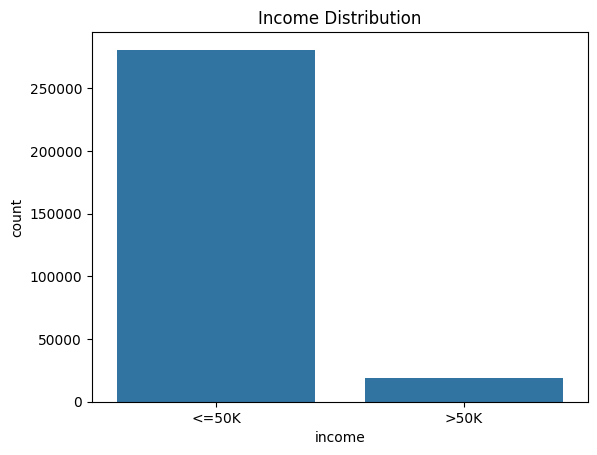

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="income")
plt.title("Income Distribution")
plt.show()

In [13]:
df["income"].value_counts(normalize=True) * 100

income
<=50K    93.79588
>50K      6.20412
Name: proportion, dtype: float64

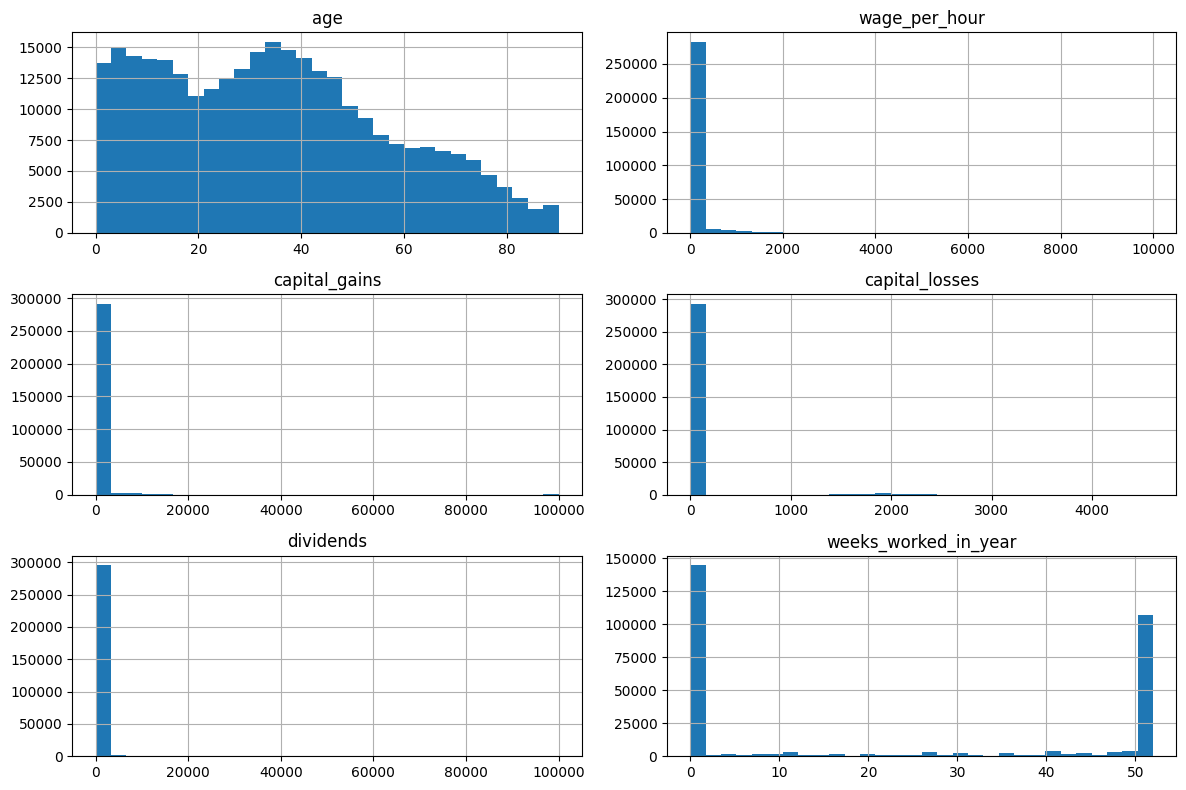

In [14]:
numeric_columns = [
    "age",
    "wage_per_hour",
    "capital_gains",
    "capital_losses",
    "dividends",
    "weeks_worked_in_year"
]

df[numeric_columns].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

In [15]:
from IPython.display import display

for column in ["education", "sex", "class_of_worker"]:
    print(column)
    display(pd.crosstab(df[column], df["income"], normalize="index").sort_values(">50K", ascending=False))


education


income,<=50K,>50K
education,,
Prof school degree (MD DDS DVM LLB JD),0.457849,0.542151
Doctorate degree(PhD EdD),0.482740,0.517260
Masters degree(MA MS MEng MEd MSW MBA),0.687824,0.312176
Bachelors degree(BA AB BS),0.802454,0.197546
Associates degree-academic program,0.908258,0.091742
Associates degree-occup /vocational,0.923459,0.076541
Some college but no degree,0.937066,0.062934
High school graduate,0.960402,0.039598
12th grade no diploma,0.985290,0.014710


sex


income,<=50K,>50K
sex,,
Male,0.898265,0.101735
Female,0.974527,0.025473


class_of_worker


income,<=50K,>50K
class_of_worker,,
Self-employed-incorporated,0.657439,0.342561
Federal government,0.798845,0.201155
Self-employed-not incorporated,0.872692,0.127308
State government,0.883015,0.116985
Local government,0.889386,0.110614
Private,0.898167,0.101833
Not in universe,0.991026,0.008974
Without pay,0.991667,0.008333
Never worked,0.996890,0.003110


In [16]:
df.groupby("income")[numeric_columns].mean().T

income,<=50K,>50K
age,33.756563,46.368106
wage_per_hour,53.479775,79.676109
capital_gains,142.981173,4797.323944
capital_losses,26.618163,191.522243
dividends,106.908235,1540.520519
weeks_worked_in_year,21.532529,48.060804


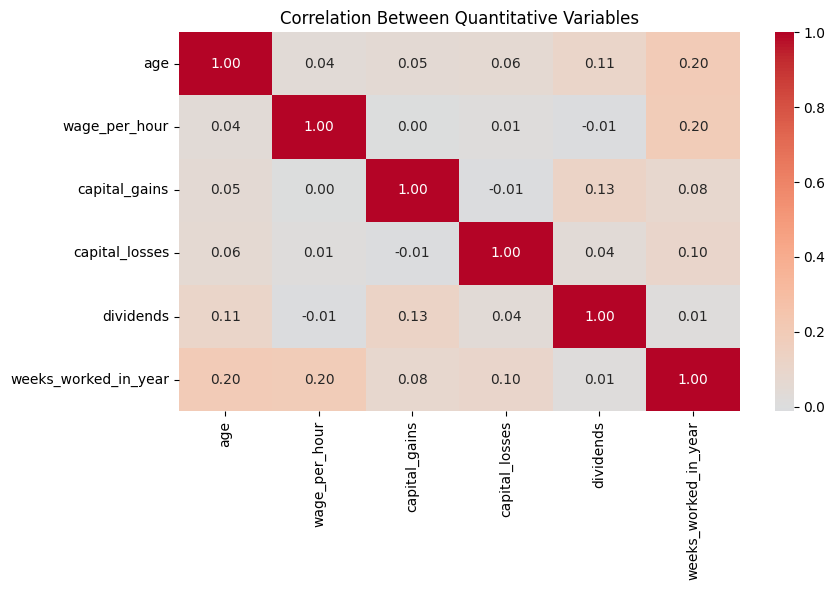

In [17]:
# Category codes are not quantitative measurements.
correlation = df[numeric_columns].corr()
plt.figure(figsize=(9, 6))
sns.heatmap(correlation, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Between Quantitative Variables")
plt.tight_layout()
plt.show()


In [18]:
unique_counts = df.nunique().sort_values(ascending=False)
unique_counts

instance_weight                    123232
dividends                            1675
wage_per_hour                        1425
capital_gains                         133
capital_losses                        114
age                                    91
weeks_worked_in_year                   53
industry_code_detailed                 52
state_prev_residence                   51
occupation_code_detailed               47
country_birth_self                     43
country_birth_mother                   43
country_birth_father                   43
household_family_status                38
industry_code_major                    24
education                              17
occupation_code_major                  15
migration_within_reg                   10
migration_msa                          10
hispanic_origin                        10
class_of_worker                         9
migration_reg                           9
household_summary                       8
employment_status                 

In [19]:
df["education"].unique()

array(['High school graduate', 'Some college but no degree', '10th grade',
       'Children', 'Bachelors degree(BA AB BS)',
       'Masters degree(MA MS MEng MEd MSW MBA)', 'Less than 1st grade',
       'Associates degree-academic program', '7th and 8th grade',
       '12th grade no diploma', 'Associates degree-occup /vocational',
       'Prof school degree (MD DDS DVM LLB JD)', '5th or 6th grade',
       '11th grade', 'Doctorate degree(PhD EdD)', '9th grade',
       '1st 2nd 3rd or 4th grade'], dtype=object)

In [20]:
for column in numeric_columns:
    print(column)
    print("Minimum:", df[column].min())
    print("Maximum:", df[column].max())
    print()

age
Minimum: 0
Maximum: 90

wage_per_hour
Minimum: 0
Maximum: 9999

capital_gains
Minimum: 0
Maximum: 99999

capital_losses
Minimum: 0
Maximum: 4608

dividends
Minimum: 0
Maximum: 99999

weeks_worked_in_year
Minimum: 0
Maximum: 52



In [21]:
summary = pd.DataFrame({
    "data_type": df.dtypes,
    "unique_values_including_unknown": df.nunique(),
    "unknown_values": df.eq("Unknown").sum(),
    "unknown_percentage": df.eq("Unknown").mean() * 100
})
summary.sort_values("unknown_percentage", ascending=False)


,data_type,unique_values_including_unknown,unknown_values,unknown_percentage
migration_msa,object,10,149642,49.999833
migration_reg,object,9,149642,49.999833
migration_within_reg,object,10,149642,49.999833
migration_sunbelt,object,4,149642,49.999833
country_birth_father,object,43,10142,3.388743
country_birth_mother,object,43,9191,3.070986
country_birth_self,object,43,5157,1.723107
hispanic_origin,object,10,1279,0.427352
state_prev_residence,object,51,1038,0.346827
citizenship,object,5,0,0.000000
